## Analysis 2: Phenotype-level Consistency (Kendall's W + Cross-profile Rank Correlation)

The goal is to determine whether gene rankings are driven by the specific phenotypic profile being queried, or whether the same genes tend to rank highly across all profiles regardless of phenotype (which would indicate a systematic scoring bias). (in short, different phenotype should have different rankings in genetic perturbations.)


We use: 
- **Kendall's W**: a coefficient of concordance over the *k* = 16 phenotypes and *n* shared perturbations
  - This measures how consistent genes are ranked across all 16 phenotypes
  - W = 0 → profiles rank genes completely independently (rankings are profile-specific, the ideal outcome for distinct phenotypes).  
  - W = 1 → all profiles rank genes in exactly the same order (systematic bias; a gene that ranks #1 for Anaphase also ranks #1 for Interphase, which is biologically implausible).  
  - Values in between indicate partial concordance; moderate W with a structured correlation matrix suggests biological sub-clusters rather than noise.

- **Cross-profile Spearman ρ matrix** — pairwise rank correlation between every pair of profiles.  
  - This measures whether two profiles rank genes differently, as expected if buscar is capturing distinct phenotypic signals
  - Positive ρ (blue) → the two profiles tend to promote the same genes, suggesting shared biology or other features that are in common.  
  - Negative ρ (red) → genes that are top hits for one profile rank poorly for the other — strong evidence of profile-specific signal.  
  - Near-zero ρ (white) → rankings are essentially independent between those two profiles.

A well-behaved analysis should show negative or near-zero off-diagonal correlations between biologically distinct profiles (e.g., Interphase vs. Prometaphase), and modest positive correlations only between phenotypically similar profiles (e.g., Metaphase and Prometaphase, or Anaphase and Apoptosis).

In [1]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(grid)
})

options(warn = -1)

In [2]:
# Input data directory
results_dir <- normalizePath('../results/logo_analysis', mustWork = TRUE)

# Output directory for this notebook's figures/tables
gene_rel_dir <- normalizePath(file.path(getwd(), 'all-plots', 'gene-ranking-relationships'), mustWork = FALSE)
dir.create(gene_rel_dir, recursive = TRUE, showWarnings = FALSE)

In [3]:
# Load real and shuffled BuSCaR outputs
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_logo_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_logo_analysis_results.parquet')) %>% as_tibble()

# Compute on_rank and off_rank independently per target.
# Lower score = better rank (rank 1). NaNs/NAs are ranked last.
rerank_by_profile <- function(input_df) {
  input_df %>%
    group_by(target) %>%
    mutate(
      on_rank = {
        ord <- order(is.na(on_buscar_scores), on_buscar_scores, perturbation)
        rank_vals <- integer(n())
        rank_vals[ord] <- seq_len(n())
        rank_vals
      },
      off_rank = {
        ord <- order(is.na(off_buscar_scores), off_buscar_scores, perturbation)
        rank_vals <- integer(n())
        rank_vals[ord] <- seq_len(n())
        rank_vals
      }
    ) %>%
    ungroup()
}

moa_results_df <- rerank_by_profile(moa_results_df)
shuffled_moa_results_df <- rerank_by_profile(shuffled_moa_results_df)

head(moa_results_df)

target,perturbation,on_buscar_scores,off_buscar_scores,is_reference_distance,proportion,is_associated,on_rank,off_rank
<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<lgl>,<int>,<int>
Grape,ENSG00000175216,0.4179060,0.08333333,FALSE,0.18681319,TRUE,1,25
Grape,ch-TOG,0.5606501,0.00000000,FALSE,0.34459459,TRUE,2,1
Grape,DNCH1,NA,NA,NA,NA,NA,60,60
Grape,ENSG00000138180,0.8288275,0.00000000,FALSE,0.05128205,TRUE,15,3
Grape,DDOST,NA,NA,NA,NA,NA,59,59
Grape,CENPE,NA,NA,NA,NA,NA,58,58


In [4]:
# Keep rows where both on/off buscar scores are present
prepare_df <- function(results_df) {
  results_df %>%
    as.data.frame() %>%
    filter(!is.na(on_buscar_scores), !is.na(off_buscar_scores))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

In [5]:
build_rank_bundle <- function(input_df, rank_col = 'on_rank') {
  rank_pivot <- input_df %>%
    select(target, perturbation, all_of(rank_col)) %>%
    pivot_wider(names_from = target, values_from = all_of(rank_col))

  rank_pivot_complete <- rank_pivot %>% drop_na()

  rank_pivot_reranked <- rank_pivot_complete %>%
    select(-perturbation) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average')))

  # Use sparse, profile-wise rank matrix for pairwise correlations.
  # This avoids collapsing to ~1 perturbation for shuffled data after complete-case filtering.
  rank_matrix_sparse <- rank_pivot %>%
    select(-perturbation) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average', na.last = 'keep')))

  list(
    rank_pivot = rank_pivot,
    rank_pivot_complete = rank_pivot_complete,
    rank_pivot_reranked = rank_pivot_reranked,
    rank_matrix_sparse = rank_matrix_sparse,
    n_subjects = nrow(rank_pivot_reranked),
    k_raters = ncol(rank_pivot_reranked),
    profile_names = colnames(rank_matrix_sparse)
  )
}

orig_on_bundle  <- build_rank_bundle(df,      rank_col = 'on_rank')
orig_off_bundle <- build_rank_bundle(df,      rank_col = 'off_rank')
shuf_on_bundle  <- build_rank_bundle(shuf_df, rank_col = 'on_rank')
shuf_off_bundle <- build_rank_bundle(shuf_df, rank_col = 'off_rank')

This analysis first measures global agreement in gene rankings across all phenotypes using Kendall's W. It then computes pairwise Spearman correlations between phenotype-specific gene rankings and visualizes them as a heatmap. Together, these metrics show whether ranking patterns are phenotype-specific or reflect a shared global trend.

In [6]:
# options for rendering the figure larger
height <- 12
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

compute_consistency <- function(bundle) {
  R_complete <- as.matrix(bundle$rank_pivot_reranked)

  if (nrow(R_complete) > 1 && ncol(R_complete) > 1) {
    rank_sums <- rowSums(R_complete)
    S <- sum((rank_sums - mean(rank_sums))^2)
    W <- (12 * S) / (bundle$k_raters^2 * (bundle$n_subjects^3 - bundle$n_subjects))
    chi2_stat <- bundle$k_raters * (bundle$n_subjects - 1) * W
    chi2_pval <- pchisq(chi2_stat, df = bundle$n_subjects - 1, lower.tail = FALSE)
    w_label <- sprintf('%.3f', W)
  } else {
    W <- NA_real_
    chi2_stat <- NA_real_
    chi2_pval <- NA_real_
    w_label <- 'NA (insufficient complete-case treatments)'
  }

  # Pairwise correlation on sparse rank matrix preserves shuffled information.
  # This avoids collapsing to ~1 treatment for shuffled data after complete-case filtering.
  R_sparse <- as.matrix(bundle$rank_matrix_sparse)
  corr_matrix <- cor(R_sparse, method = 'spearman', use = 'pairwise.complete.obs')

  diag(corr_matrix) <- 1
  corr_long <- as.data.frame(as.table(corr_matrix))
  colnames(corr_long) <- c('y', 'x', '\u03c1')
  corr_long$x <- factor(corr_long$x, levels = bundle$profile_names)
  corr_long$y <- factor(corr_long$y, levels = rev(bundle$profile_names))

  list(
    W = W,
    w_label = w_label,
    chi2_stat = chi2_stat,
    chi2_pval = chi2_pval,
    corr_matrix = corr_matrix,
    corr_long = corr_long,
    n_subjects = bundle$n_subjects,
    k_raters = bundle$k_raters
  )
}

plot_corr_heatmap <- function(consistency, title_suffix = '') {
  ggplot(consistency$corr_long, aes(x = x, y = y, fill = .data$rho)) +
    geom_tile(color = 'white', linewidth = 0.3) +
    geom_text(aes(label = ifelse(is.na(.data$rho), 'NA', sprintf('%.2f', .data$rho))), size = 6.3, color = '#222222') +
    scale_fill_gradient2(
      low = '#d62728',
      mid = '#f7f7f7',
      high = '#1f77b4',
      midpoint = 0,
      limits = c(-1, 1),
      na.value = 'grey80'
    ) +
    labs(
      title = sprintf(
        "Cross-phenotype Spearman rank correlation \u03c1 %s\nKendall's W = %s  (complete-case n = %d, %d phenotypic states)",
        title_suffix, consistency$w_label, consistency$n_subjects, consistency$k_raters
      ),
      x = NULL,
      y = NULL,
      fill = 'Spearman \u03c1'
    ) +
    guides(fill = guide_colorbar(title.position = 'top', title.hjust = 0.5)) +
    theme_minimal(base_size = 20) +
    theme(
      plot.title = element_text(face = 'bold', size = 25, hjust = 0.5, color = '#1a1a2e'),
      axis.text.x = element_text(angle = 45, hjust = 1, size = 20, color = '#222222'),
      axis.text.y = element_text(size = 20, color = '#222222'),
      legend.title = element_text(face = 'bold', size = 22, color = '#1a1a2e'),
      legend.text = element_text(size = 20, color = '#222222'),
      panel.grid = element_blank()
    )
}

save_and_print_corr <- function(consistency, file_name, title_suffix = '', label = 'original') {
  cat(sprintf("[%s] Kendall's W = %s\n", label, consistency$w_label))
  cat(sprintf('[%s] complete-case n = %d, k = %d\n', label, consistency$n_subjects, consistency$k_raters))

  if (!is.na(consistency$chi2_stat)) {
    cat(sprintf('[%s] \u03c7\u00b2(%d) = %.4f,  p = %.4e\n', label, consistency$n_subjects - 1, consistency$chi2_stat, consistency$chi2_pval))
  }

  p_corr <- plot_corr_heatmap(consistency, title_suffix)
  out_path <- file.path(gene_rel_dir, file_name)
  ggsave(out_path, p_corr, width = width, height = height, dpi = 300, bg = 'white')
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
  print(p_corr)
}

# Assign the ρ symbol to a variable for safe column naming
rho_sym <- '\u03c1'

orig_on_consistency  <- compute_consistency(orig_on_bundle)
orig_off_consistency <- compute_consistency(orig_off_bundle)
shuf_on_consistency  <- compute_consistency(shuf_on_bundle)
shuf_off_consistency <- compute_consistency(shuf_off_bundle)

[original on_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/original_on_rank_clustermap.png
[original off_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/original_off_rank_clustermap.png


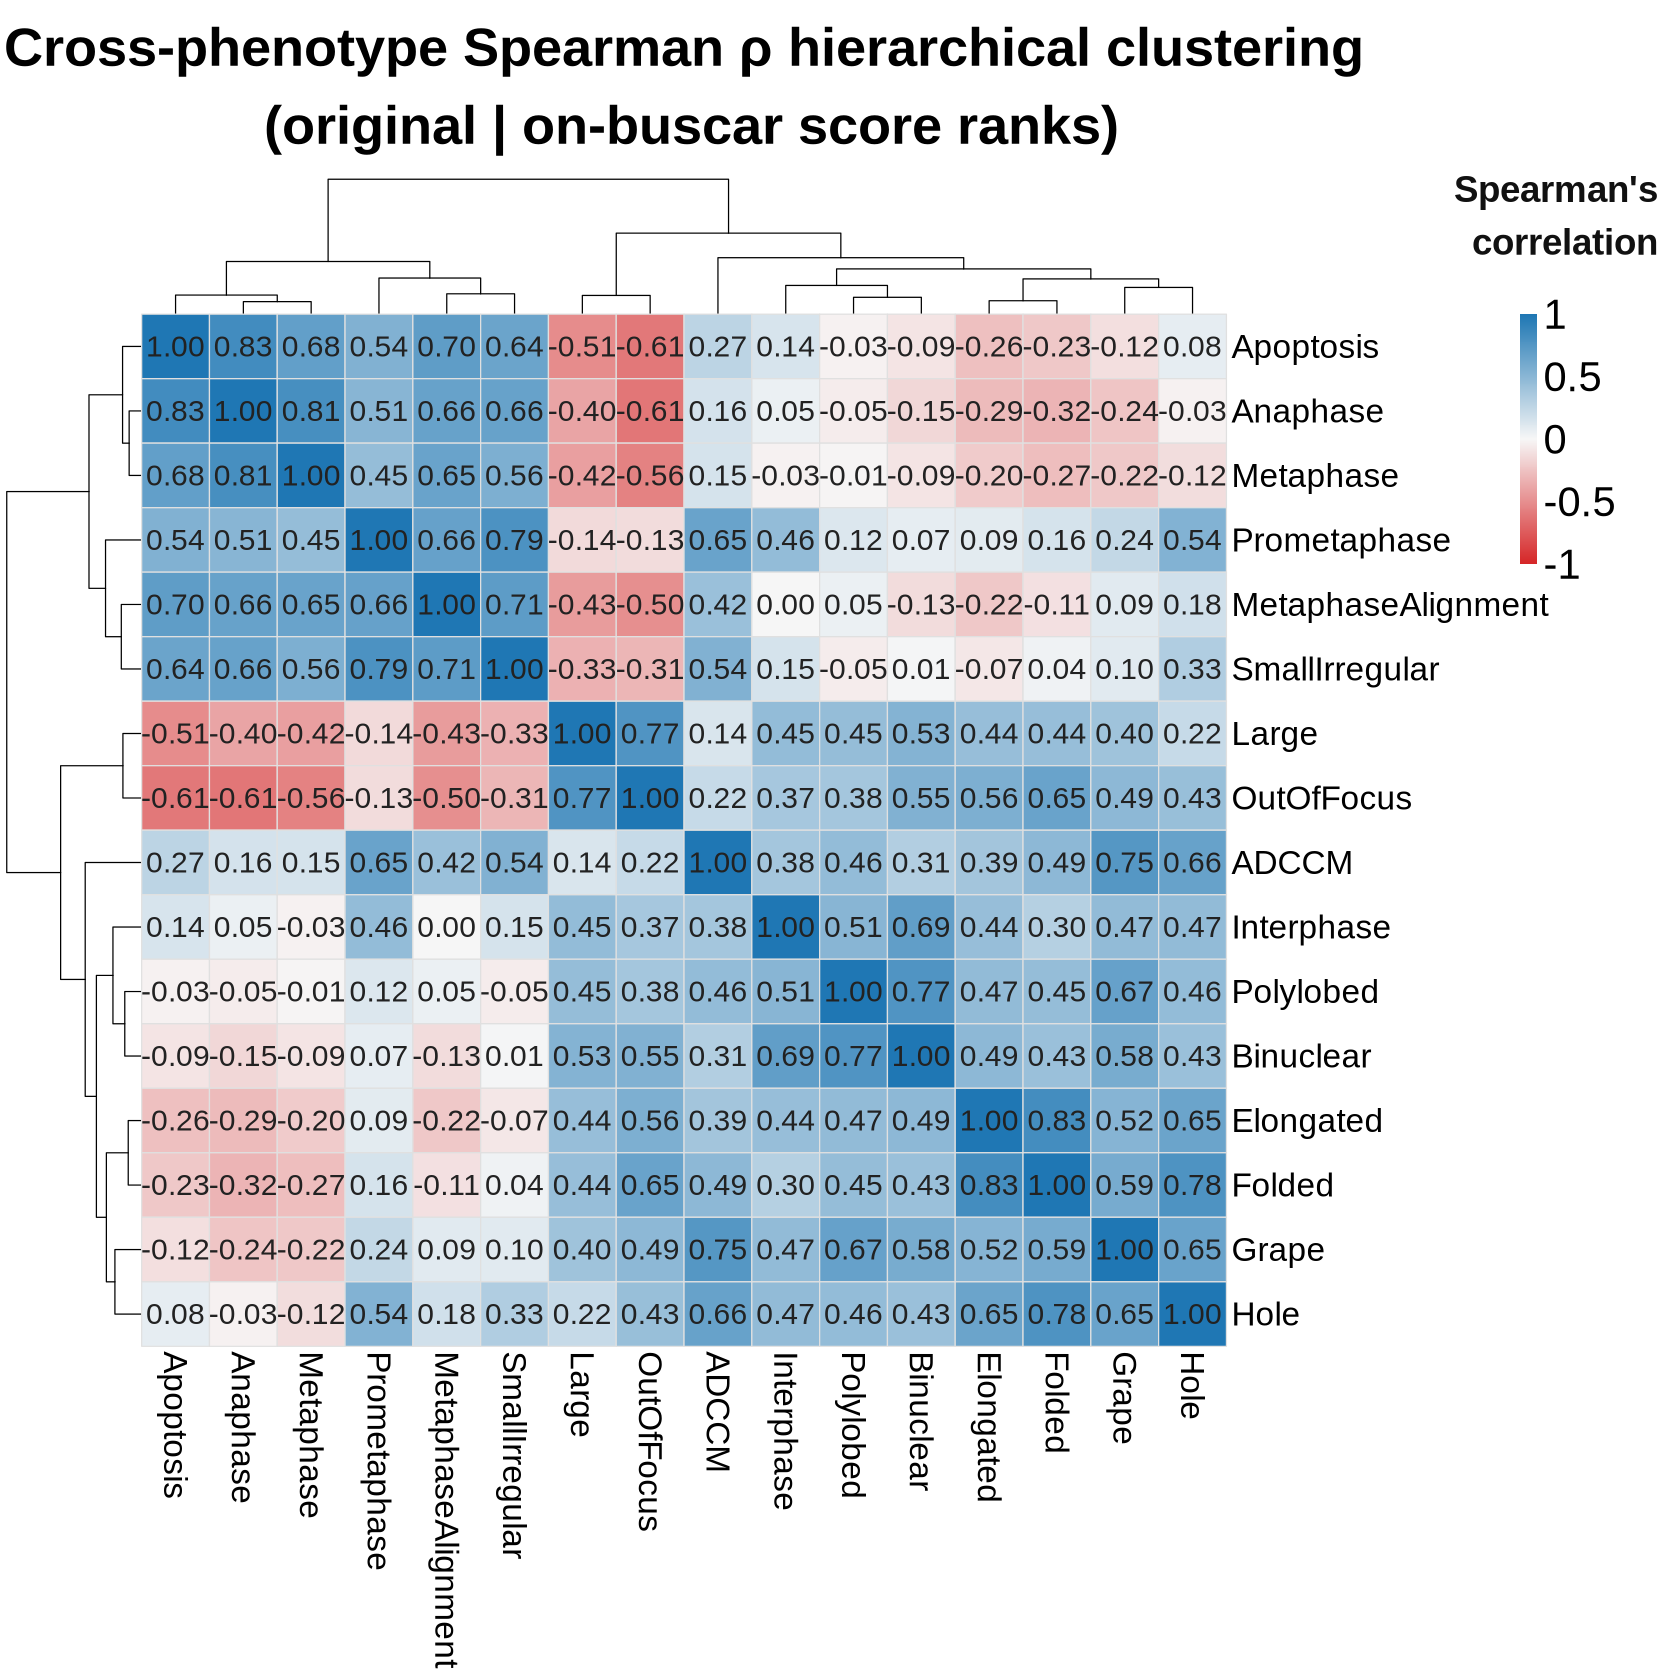

[shuffled on_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_on_rank_clustermap.png


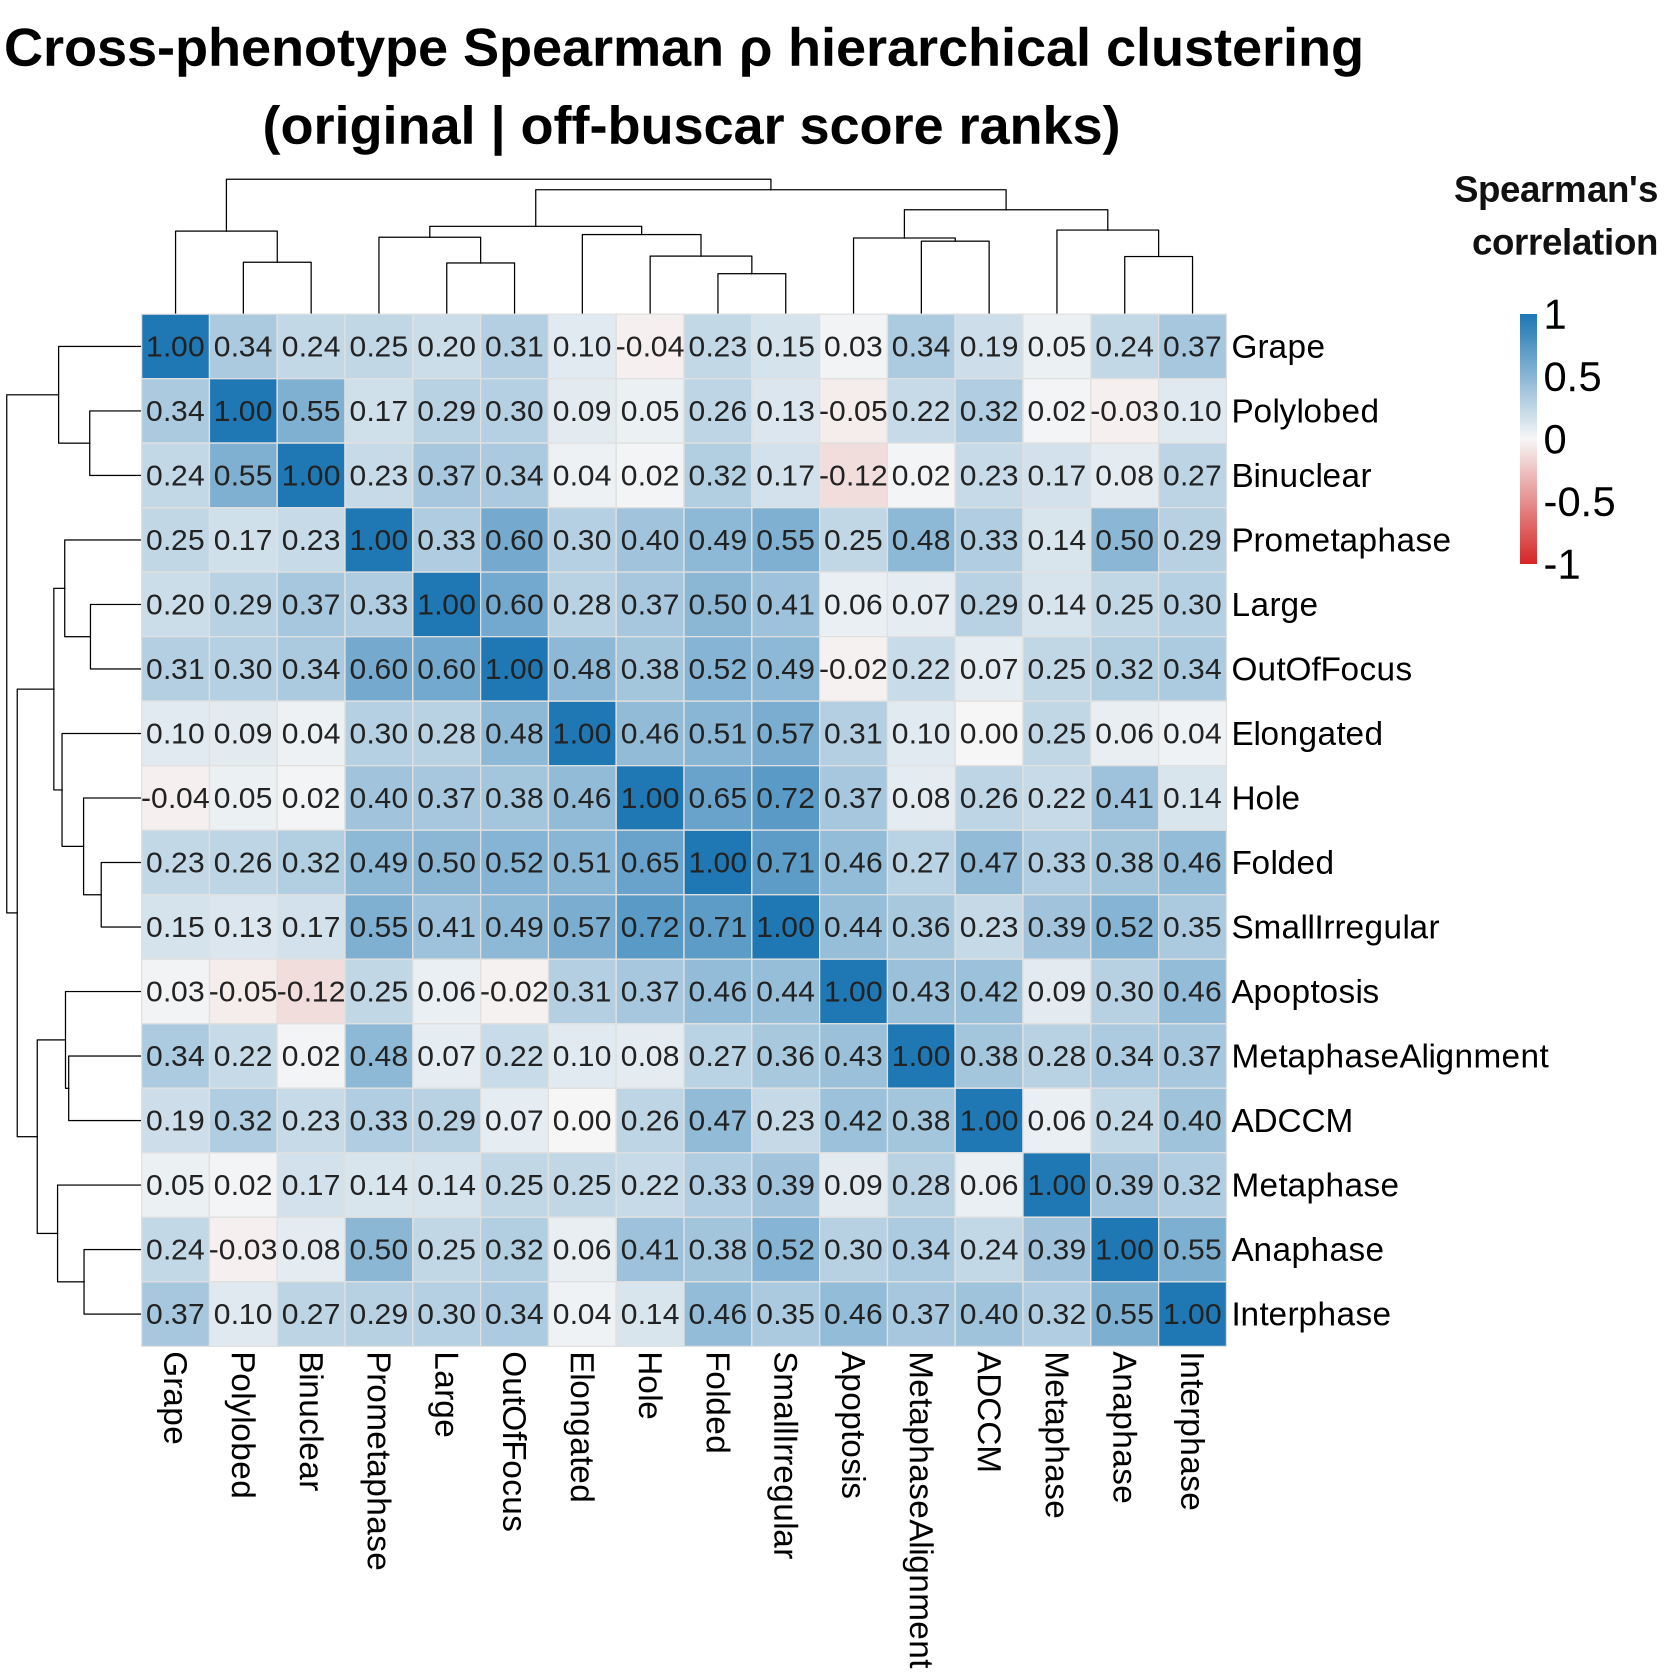

[shuffled off_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_off_rank_clustermap.png


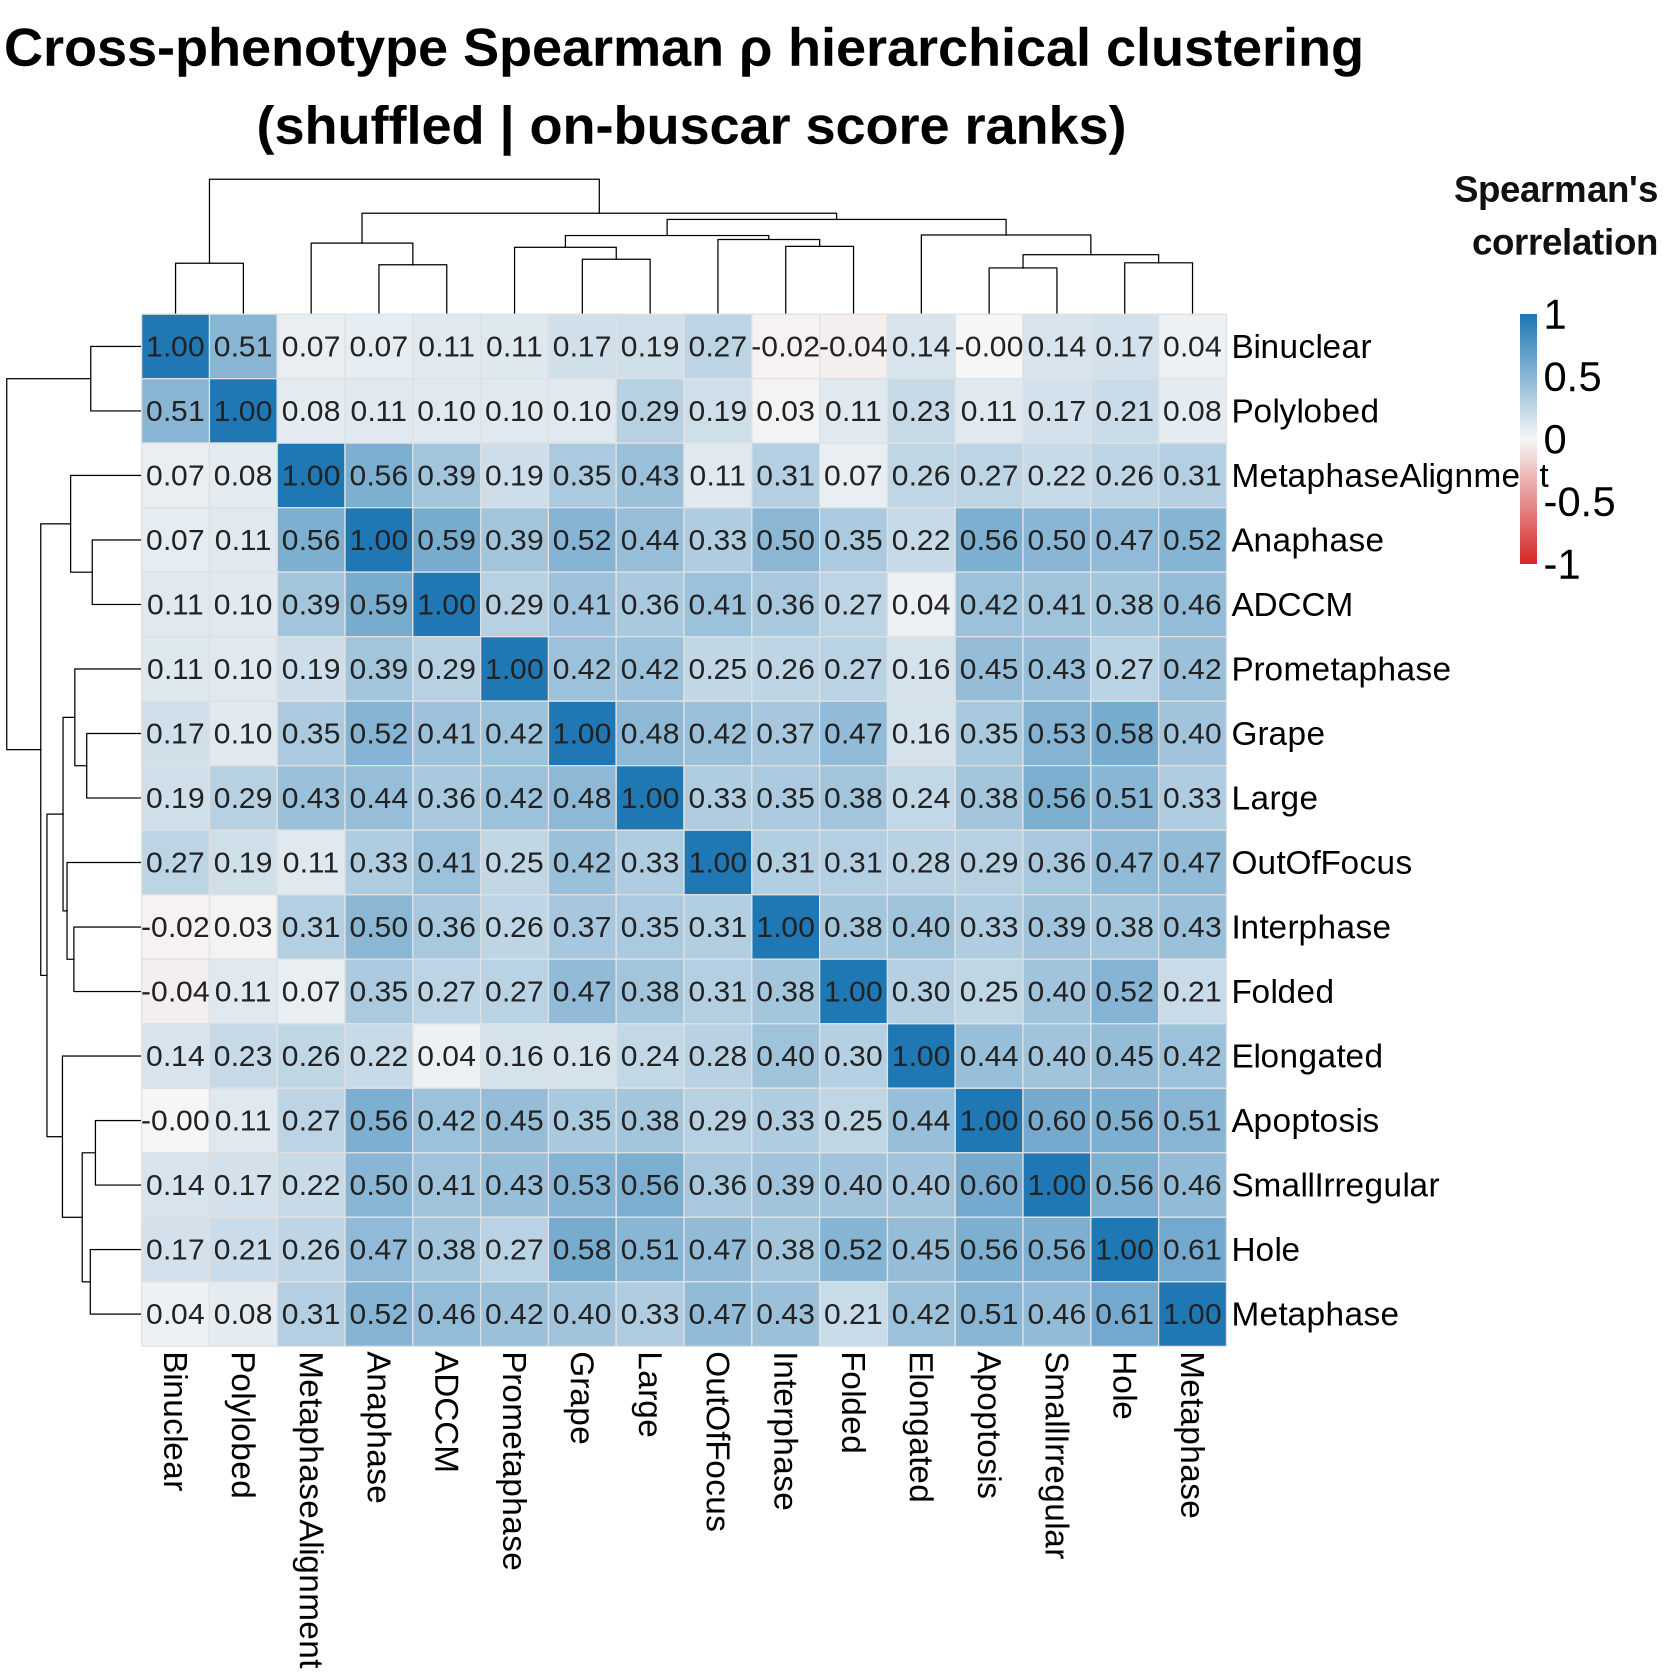

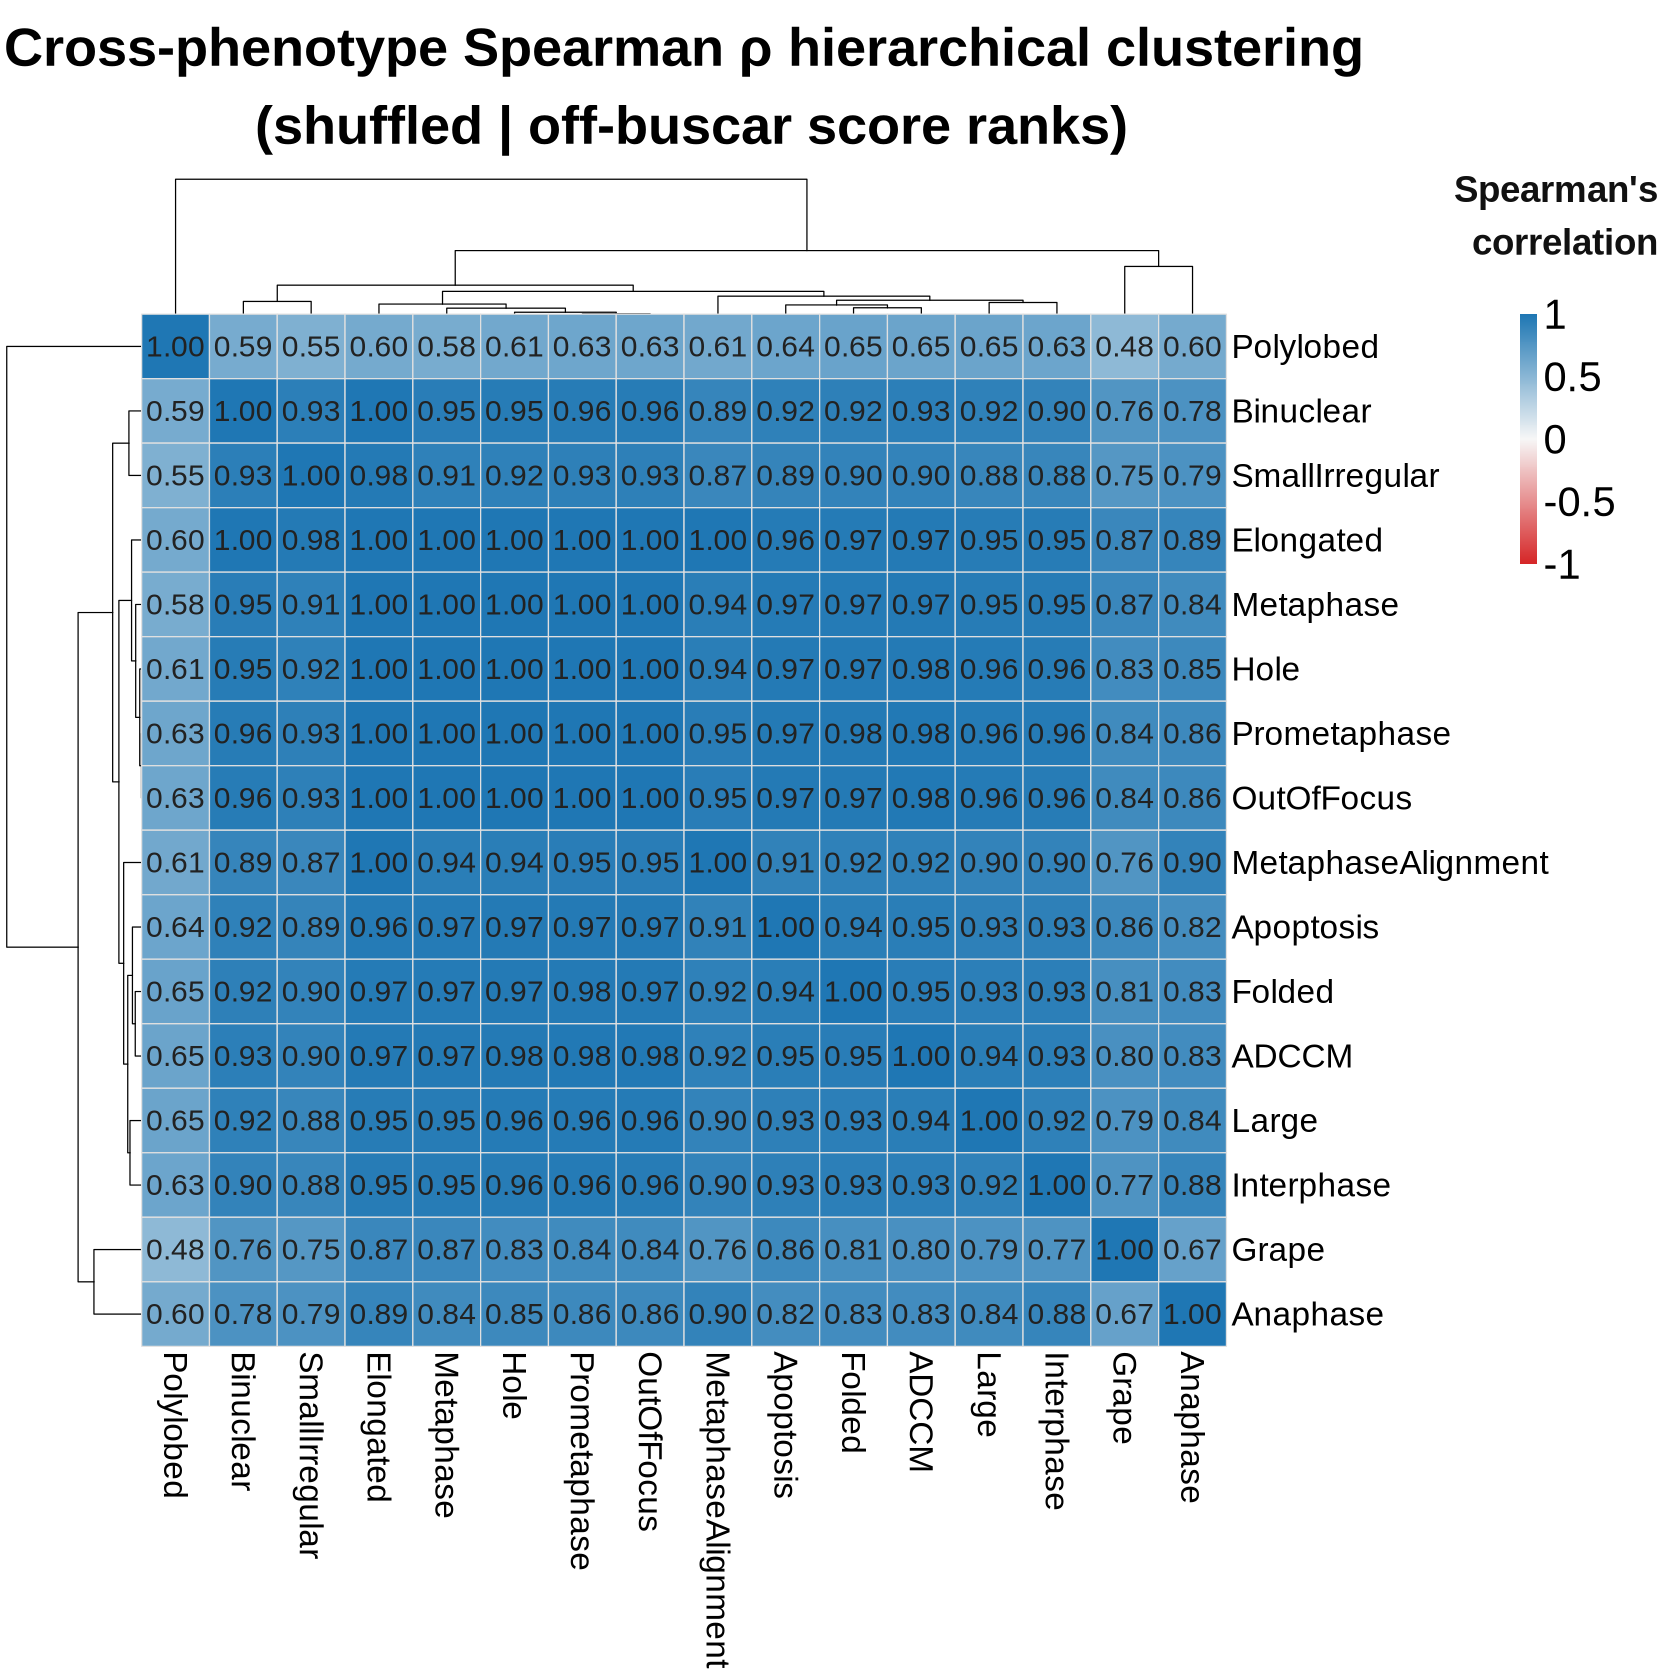

In [7]:
# options for rendering the figure larger
height <- 14
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

save_corr_clustermap <- function(consistency, file_name, title_suffix = '', label = 'original', top_right_text = '') {
  corr_clean <- consistency$corr_matrix
  corr_clean[is.na(corr_clean)] <- 0

  anno_numbers <- ifelse(is.na(consistency$corr_matrix), 'NA', sprintf('%.2f', consistency$corr_matrix))
  dim(anno_numbers) <- dim(consistency$corr_matrix)

  pheat <- pheatmap(
    corr_clean,
    color = colorRampPalette(c('#d62728', '#f7f7f7', '#1f77b4'))(256),
    breaks = seq(-1, 1, length.out = 257),
    cluster_rows = TRUE,
    cluster_cols = TRUE,
    treeheight_row = 80,
    treeheight_col = 80,
    display_numbers = anno_numbers,
    number_color = '#222222',
    fontsize = 25,
    fontsize_row = 20,
    fontsize_col = 20,
    fontsize_number = 18,
    border_color = '#e0e0e0',
    silent = TRUE,
    legend = TRUE,
    main = sprintf(
      "Cross-phenotype Spearman \u03c1 hierarchical clustering\n%s",
      title_suffix
    )
  )

  pheat_grob <- pheat$gtable
  
  # Robustly shift the legend to the left
  idx <- which(pheat_grob$layout$name == "legend")
  if (length(idx) > 0) {
    leg_grob <- pheat_grob$grobs[[idx]]
    
    # Check if viewport exists
    if (!is.null(leg_grob$vp)) {
      # Use the 'update' or direct assignment if it's a simple unit
      # Handling potential coercion issues by checking length and type
      curr_x <- leg_grob$vp$x
      if (grid::is.unit(curr_x)) {
         # Direct assignment with unit arithmetic
         leg_grob$vp$x <- curr_x - grid::unit(2, "lines")
         pheat_grob$grobs[[idx]] <- leg_grob
      }
    } else {
      # If no viewport, we can try to shift the layout column width slightly
      # or wrap the grob in a new viewport that handles the offset
      pheat_grob$grobs[[idx]] <- grid::editGrob(leg_grob, vp = grid::viewport(x = grid::unit(1, "npc") - grid::unit(2, "lines")))
    }
  }

  # Add text to top right corner if provided
  if (top_right_text != '') {
    draw_corner_text <- function() {
      grid::grid.text(
        top_right_text, 
        x = grid::unit(1, "npc") - grid::unit(0.5, "lines"), 
        y = grid::unit(1, "npc") - grid::unit(4, "lines"),
        just = c("right", "top"),
        gp = grid::gpar(fontsize = 22, fontface = "bold", col = "#111111")
      )
    }
  } else {
    draw_corner_text <- function() {}
  }

  out_path <- file.path(gene_rel_dir, file_name)
  
  # Save to file
  png(out_path, width = 14, height = 15, units = 'in', res = 300)
  grid::grid.newpage()
  grid::grid.draw(pheat_grob)
  draw_corner_text() # Draw text LAST
  dev.off()
  
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
  
  # Display in notebook
  grid::grid.newpage()
  grid::grid.draw(pheat_grob)
  draw_corner_text() # Draw text LAST
}

# Original data — on_rank
save_corr_clustermap(
    orig_on_consistency, 
    'original_on_rank_clustermap.png', 
    ' (original | on-buscar score ranks)', 
    'original on_rank',
    top_right_text = "Spearman's\ncorrelation"
)

# Original data — off_rank
save_corr_clustermap(
    orig_off_consistency, 
    'original_off_rank_clustermap.png', 
    ' (original | off-buscar score ranks)', 
    'original off_rank',
    top_right_text = "Spearman's\ncorrelation"
)

# Shuffled data — on_rank
save_corr_clustermap(
    shuf_on_consistency,  
    'shuffled_on_rank_clustermap.png',  
    ' (shuffled | on-buscar score ranks)',  
    'shuffled on_rank',
    top_right_text = "Spearman's\ncorrelation"
)

# Shuffled data — off_rank
save_corr_clustermap(
    shuf_off_consistency, 
    'shuffled_off_rank_clustermap.png', 
    ' (shuffled | off-buscar score ranks)', 
    'shuffled off_rank',
    top_right_text = "Spearman's\ncorrelation"
)


The real data (W = 0.348) produced biologically coherent clusters  mitotic phenotypes (Prometaphase, Anaphase, Metaphase) grouped together with high positive correlations, while morphologically distinct states like Large and OutOfFocus showed negative correlations against the mitotic cluster. The shuffled data (W = 0.528) lost this entirely, collapsing into uniformly moderate positive correlations with no meaningful clustering structure and no negative correlations.

## Real vs Permutation Null

This section tests whether the observed concordance in gene rankings (Kendall's W) is driven by genuine biological signal or is simply a structural artifact of the data.

- **Real W**: concordance computed from the original gene rankings across all phenotypic states.
- **Permutation-null W**: concordance after randomly shuffling which gene receives which row of rankings (label permutation). This preserves each gene's rank profile but breaks the alignment between genes and profiles, destroying any real signal while keeping data structure intact.

**Interpretation:** if real W is much larger than the permutation null distribution, the observed agreement across phenotypes is unlikely to have arisen by chance.


In [8]:
# Compute Kendall's W (and chi-square p-value) from a complete-case rank matrix
compute_kendall_w_from_matrix <- function(rank_matrix_complete) {
  n_subjects <- nrow(rank_matrix_complete)
  k_raters <- ncol(rank_matrix_complete)

  if (n_subjects <= 1 || k_raters <= 1) {
    return(list(
      W = NA_real_,
      p_value = NA_real_,
      chi2_stat = NA_real_,
      n_subjects = n_subjects,
      k_raters = k_raters
    ))
  }

  row_rank_sums <- rowSums(rank_matrix_complete)
  S <- sum((row_rank_sums - mean(row_rank_sums))^2)
  W <- (12 * S) / (k_raters^2 * (n_subjects^3 - n_subjects))

  chi2_stat <- k_raters * (n_subjects - 1) * W
  p_value <- pchisq(chi2_stat, df = n_subjects - 1, lower.tail = FALSE)

  list(
    W = W,
    p_value = p_value,
    chi2_stat = chi2_stat,
    n_subjects = n_subjects,
    k_raters = k_raters
  )
}

In [9]:
# Build complete-case rank matrices from original and shuffled data and compute observed W
R_real <- as.matrix(orig_on_bundle$rank_pivot_reranked)
R_shuf <- as.matrix(shuf_on_bundle$rank_pivot_reranked)

real_stats <- compute_kendall_w_from_matrix(R_real)
shuf_stats <- compute_kendall_w_from_matrix(R_shuf)

cat(sprintf('Observed W (original) = %.3f\n', real_stats$W))
cat(sprintf('Observed W (shuffled) = %.3f\n', shuf_stats$W))


Observed W (original) = 0.308


Observed W (shuffled) = 0.406


In [10]:
# Permutation settings
set.seed(0)
n_permutations <- 5000

# Null model: for each phenotype column, independently shuffle which gene receives
# which rank. This keeps the within-phenotype rank distribution intact but destroys
# the cross-phenotype concordance signal -- the standard null for Kendall's W.
perm_W <- replicate(n_permutations, {
  R_perm <- apply(R_real, 2, sample, replace = FALSE)
  if (is.vector(R_perm)) R_perm <- matrix(R_perm, ncol = ncol(R_real))
  compute_kendall_w_from_matrix(R_perm)$W
})

perm_W <- perm_W[!is.na(perm_W)]
empirical_p_real <- if (length(perm_W) > 0) mean(perm_W >= real_stats$W) else NA_real_
z_vs_perm <- if (length(perm_W) > 1 && sd(perm_W) > 0) (real_stats$W - mean(perm_W)) / sd(perm_W) else NA_real_

summary_tbl <- tibble::tibble(
  comparison = c('real', 'perm_null_mean', 'perm_null_sd', 'empirical_p_real_vs_perm', 'zscore_real_vs_perm'),
  value = c(
    real_stats$W,
    ifelse(length(perm_W) > 0, mean(perm_W), NA_real_),
    ifelse(length(perm_W) > 1, sd(perm_W), NA_real_),
    empirical_p_real,
    z_vs_perm
  )
)

print(summary_tbl)

summary_out <- file.path(gene_rel_dir, 'kendall_w_real_permutation_summary.csv')
readr::write_csv(summary_tbl, summary_out)
cat(sprintf('Saved -> %s\n', summary_out))


# A tibble: 5 × 2
  comparison                 value
  <chr>                      <dbl>
1 real                      0.308 
2 perm_null_mean            0.0626
3 perm_null_sd              0.0155
4 empirical_p_real_vs_perm  0     
5 zscore_real_vs_perm      15.9   
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_real_permutation_summary.csv


Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_permutation_null_histogram.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_specificity_real_vs_shuffled.csv
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_specificity_real_vs_shuffled_wide.csv


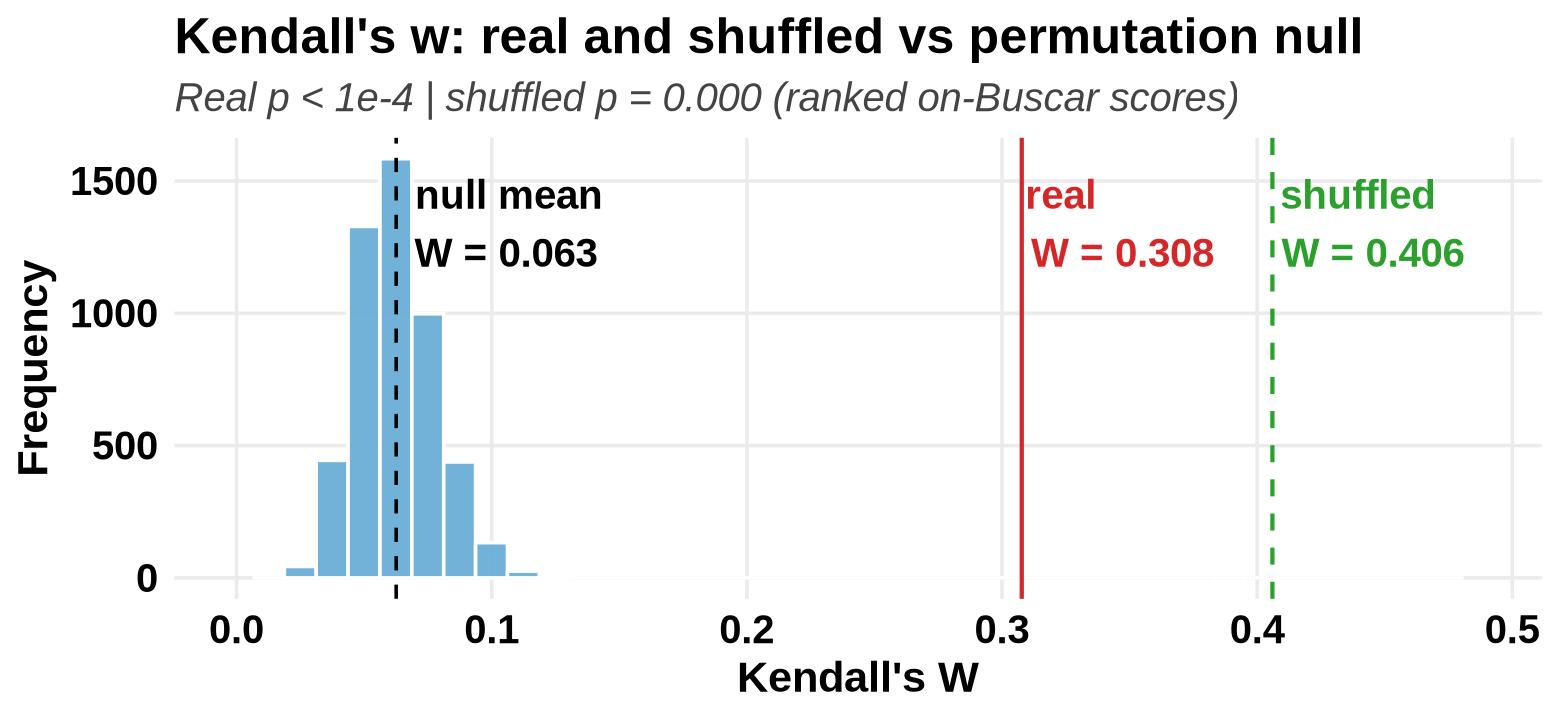

In [20]:
# Plot the permutation-null distribution with real and shuffled W as reference lines
plot_df <- tibble::tibble(W = perm_W)
perm_mean <- mean(perm_W)

# Use a compact aspect ratio for this histogram (both display and saved file).
plot_width <- 13
plot_height <- 6
options(repr.plot.width = plot_width, repr.plot.height = plot_height)

x_upper <- max(c(perm_W, real_stats$W, shuf_stats$W), na.rm = TRUE) * 1.2
x_upper <- max(x_upper, 0.12)

empirical_p_shuf <- if (length(perm_W) > 0) mean(perm_W >= shuf_stats$W) else NA_real_

# Keep labels readable even when a reference line is near the right boundary.
shuf_hjust <- ifelse(shuf_stats$W > x_upper * 0.88, 1.05, -0.05)
# Moving shuffled W label bit higher by reducing vjust (smaller value = higher in ggplot text)
shuf_vjust <- ifelse(shuf_stats$W > x_upper * 0.88, 1.5, 1.5)

p_perm <- ggplot(plot_df, aes(x = W)) +
  geom_histogram(bins = 40, fill = '#6baed6', color = 'white', alpha = 0.95) +
  geom_vline(xintercept = real_stats$W, color = '#d62728', linewidth = 1.2) +
  geom_vline(xintercept = shuf_stats$W, color = '#2ca02c', linewidth = 1.2, linetype = 'dashed') +
  geom_vline(xintercept = perm_mean, color = 'black', linewidth = 1.0, linetype = 'dashed') +
  annotate(
    'text', x = real_stats$W, y = Inf,
    label = sprintf('real\nW = %.3f', real_stats$W),
    vjust = 1.5, hjust = -0.05, color = '#d62728', size = 8.5, fontface = 'bold'
  ) +
  annotate(
    'text', x = shuf_stats$W, y = Inf,
    label = sprintf('shuffled\nW = %.3f', shuf_stats$W),
    vjust = shuf_vjust, hjust = shuf_hjust, color = '#2ca02c', size = 8.5, fontface = 'bold'
  ) +
  annotate(
    'text', x = perm_mean, y = Inf,
    label = sprintf('null mean\nW = %.3f', perm_mean),
    vjust = 1.5, hjust = -0.1, color = 'black', size = 8.5, fontface = 'bold'
  ) +
  scale_x_continuous(limits = c(0, x_upper)) +
  labs(
    title = "Kendall's w: real and shuffled vs permutation null",
    subtitle = sprintf("Real p < 1e-4 | shuffled p = %.3f (ranked on-Buscar scores)", empirical_p_shuf),
    x = "Kendall's W",
    y = 'Frequency'
  ) +
  theme_minimal(base_size = 22) +
  theme(
    plot.title    = element_text(face = 'bold', size = 30),
    plot.subtitle = element_text(face = 'italic', size = 24, color = '#444444', margin = margin(b = 10)),
    axis.text.x   = element_text(face = 'bold', colour = 'black', size = 24),
    axis.text.y   = element_text(face = 'bold', colour = 'black', size = 24),
    axis.title.x  = element_text(face = 'bold', size = 26),
    axis.title.y  = element_text(face = 'bold', size = 26),
    panel.grid.minor = element_blank()
  )

perm_plot_out <- file.path(gene_rel_dir, 'kendall_w_permutation_null_histogram.png')
ggsave(perm_plot_out, p_perm, width = plot_width, height = plot_height, dpi = 300, bg = 'white')
cat(sprintf('Saved -> %s\n', perm_plot_out))


# Summarize phenotype specificity as mean off-diagonal Spearman correlation per profile
# for both original and shuffled feature spaces.
compute_profile_specificity <- function(corr_matrix, feature_space_label) {
  # Define the rho symbol string safely
  rho_sym <- "\u03c1"
  col_name <- paste0("mean_", rho_sym)
  
  res <- tibble::tibble(profile = colnames(corr_matrix))
  res[[col_name]] <- sapply(res$profile, function(p) {
    v <- corr_matrix[p, setdiff(colnames(corr_matrix), p)]
    mean(v, na.rm = TRUE)
  })
  res$feature_space <- feature_space_label
  
  res
}

profile_specificity_real <- compute_profile_specificity(orig_on_consistency$corr_matrix, 'original')
profile_specificity_shuf <- compute_profile_specificity(shuf_on_consistency$corr_matrix, 'shuffled')

profile_specificity <- bind_rows(profile_specificity_real, profile_specificity_shuf)

# Identify the rho column dynamically for sorting
rho_col <- grep("mean_", colnames(profile_specificity), value = TRUE)
profile_specificity <- profile_specificity %>%
  arrange(feature_space, .data[[rho_col]])

spec_long_out <- file.path(gene_rel_dir, 'profile_specificity_real_vs_shuffled.csv')
readr::write_csv(profile_specificity, spec_long_out)
cat(sprintf('Saved -> %s\n', spec_long_out))

profile_specificity_wide <- profile_specificity %>%
  select(profile, feature_space, all_of(rho_col)) %>%
  tidyr::pivot_wider(names_from = feature_space, values_from = all_of(rho_col))

if (all(c('original', 'shuffled') %in% colnames(profile_specificity_wide))) {
  profile_specificity_wide <- profile_specificity_wide %>%
    mutate(delta_real_minus_shuffled = original - shuffled) %>%
    arrange(delta_real_minus_shuffled)
}

spec_wide_out <- file.path(gene_rel_dir, 'profile_specificity_real_vs_shuffled_wide.csv')
readr::write_csv(profile_specificity_wide, spec_wide_out)
cat(sprintf('Saved -> %s\n', spec_wide_out))


p_perm

## Permutation Null for off-buscar ranks

Repeating the concordant measure for off-target rankings.


Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_off_rank_permutation_null_histogram.png


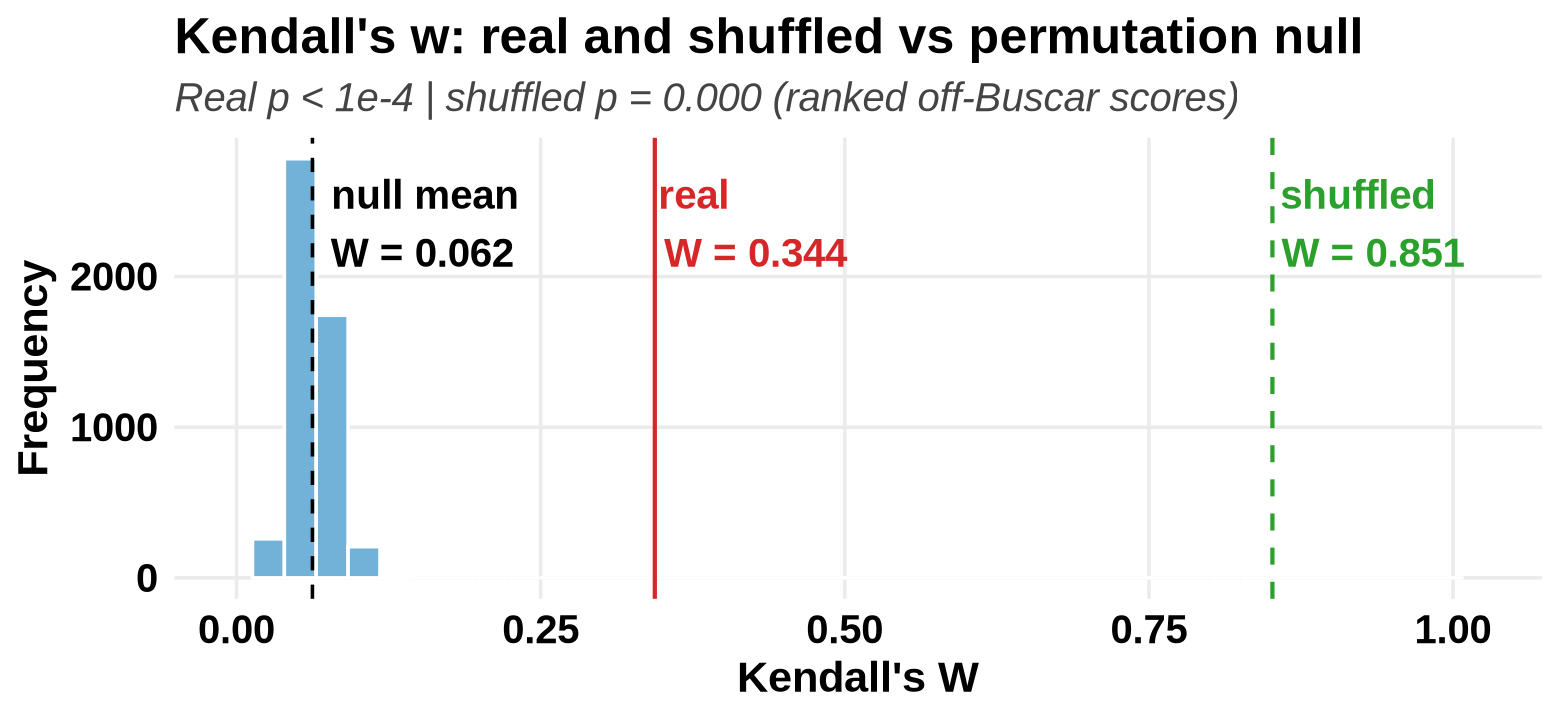

In [19]:
# Compute off-rank stats
R_real_off <- as.matrix(orig_off_bundle$rank_pivot_reranked)
R_shuf_off <- as.matrix(shuf_off_bundle$rank_pivot_reranked)

real_stats_off <- compute_kendall_w_from_matrix(R_real_off)
shuf_stats_off <- compute_kendall_w_from_matrix(R_shuf_off)

# Permutation settings (reuse 5000 from before)
set.seed(0)
perm_W_off <- replicate(n_permutations, {
  R_perm <- apply(R_real_off, 2, sample, replace = FALSE)
  if (is.vector(R_perm)) R_perm <- matrix(R_perm, ncol = ncol(R_real_off))
  compute_kendall_w_from_matrix(R_perm)$W
})

perm_W_off <- perm_W_off[!is.na(perm_W_off)]
empirical_p_shuf_off <- if (length(perm_W_off) > 0) mean(perm_W_off >= shuf_stats_off$W) else NA_real_

# Plotting
plot_df_off <- tibble::tibble(W = perm_W_off)
perm_mean_off <- mean(perm_W_off)

x_upper_off <- max(c(perm_W_off, real_stats_off$W, shuf_stats_off$W), na.rm = TRUE) * 1.2
x_upper_off <- max(x_upper_off, 0.12)

shuf_hjust_off <- ifelse(shuf_stats_off$W > x_upper_off * 0.88, 1.05, -0.05)

p_perm_off <- ggplot(plot_df_off, aes(x = W)) +
  geom_histogram(bins = 40, fill = '#6baed6', color = 'white', alpha = 0.95) +
  geom_vline(xintercept = real_stats_off$W, color = '#d62728', linewidth = 1.2) +
  geom_vline(xintercept = shuf_stats_off$W, color = '#2ca02c', linewidth = 1.2, linetype = 'dashed') +
  geom_vline(xintercept = perm_mean_off, color = 'black', linewidth = 1.0, linetype = 'dashed') +
  annotate(
    'text', x = real_stats_off$W, y = Inf,
    label = sprintf('real\nW = %.3f', real_stats_off$W),
    vjust = 1.5, hjust = -0.05, color = '#d62728', size = 8.5, fontface = 'bold'
  ) +
  annotate(
    'text', x = shuf_stats_off$W, y = Inf,
    label = sprintf('shuffled\nW = %.3f', shuf_stats_off$W),
    vjust = 1.5, hjust = shuf_hjust_off, color = '#2ca02c', size = 8.5, fontface = 'bold'
  ) +
  annotate(
    'text', x = perm_mean_off, y = Inf,
    label = sprintf('null mean\nW = %.3f', perm_mean_off),
    vjust = 1.5, hjust = -0.1, color = 'black', size = 8.5, fontface = 'bold'
  ) +
  scale_x_continuous(limits = c(0, x_upper_off)) +
  labs(
    title = "Kendall's w: real and shuffled vs permutation null",
    subtitle = sprintf("Real p < 1e-4 | shuffled p = %.3f (ranked off-Buscar scores)", empirical_p_shuf_off),
    x = "Kendall's W",
    y = 'Frequency'
  ) +
  theme_minimal(base_size = 22) +
  theme(
    plot.title    = element_text(face = 'bold', size = 30),
    plot.subtitle = element_text(face = 'italic', size = 24, color = '#444444', margin = margin(b = 10)),
    axis.text.x   = element_text(face = 'bold', colour = 'black', size = 24),
    axis.text.y   = element_text(face = 'bold', colour = 'black', size = 24),
    axis.title.x  = element_text(face = 'bold', size = 26),
    axis.title.y  = element_text(face = 'bold', size = 26),
    panel.grid.minor = element_blank()
  )

perm_plot_off_out <- file.path(gene_rel_dir, 'kendall_w_off_rank_permutation_null_histogram.png')
ggsave(perm_plot_off_out, p_perm_off, width = 13, height = 6, dpi = 300, bg = 'white')
cat(sprintf('Saved -> %s\n', perm_plot_off_out))

p_perm_off